# Minimum detectable effects for the principal nulls

**Objective.** Replace vague "no evidence" language with a transparent
statement of what each existing design was precise enough to detect. This
notebook uses saved HAC/bootstrap standard errors and the conventional
two-sided 5% level with 80% power.

**Status.** Arithmetic precision audit on already-opened aggregate results.
MDE is not evidence that the true effect is zero. The design was declared in
`examiner_facing_analysis_pack_v1_20260812.json` before this notebook ran.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import norm

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.evaluate import block_bootstrap_mean  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.thresholds import (  # noqa: E402
    FEATURES,
    SEED as THRESHOLD_SEED,
    gate_daily_portfolio,
    make_models,
    prepare_gate_frame,
    split_gate_frame,
)

apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

ALPHA = 0.05
POWER = 0.80
Z_POWER = norm.ppf(POWER)
THRESHOLD_PAIRED_SEED = 20260831
OUTPUT = ROOT / "final_experiments/outputs/77_null_minimum_detectable_effects"
SPEC_PATH = ROOT / "final_experiments/frozen_specs/examiner_facing_analysis_pack_v1_20260812.json"
TABLE_OUTPUT = ROOT / "dissertation/tables/tab_null_mde.tex"
OUTPUT.mkdir(parents=True, exist_ok=True)
TABLE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)

PATHS = {
    "conditional": ROOT / "final_experiments/outputs/71_conditional_negative_share_transfer/conditional_coefficients.csv",
    "story_type": ROOT / "final_experiments/outputs/08_story_type/development_type_interactions.csv",
    "earnings": ROOT / "final_experiments/outputs/09_earnings/development_earnings_interactions.csv",
    "publisher": ROOT / "final_experiments/outputs/15_lseg_gemma_publisher_conditioning/primary_4_arm_results.csv",
    "threshold_results": ROOT / "final_experiments/outputs/10_thresholds/evaluation_gate_comparison.csv",
    "threshold_specs": ROOT / "final_experiments/outputs/10_thresholds/frozen_gate_specs.csv",
    "threshold_agg": ROOT / "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet",
    "threshold_surprise": ROOT / "final_experiments/outputs/04_surprise/firm_day_surprise.parquet",
}


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def mde_multiplier(alpha: float, power: float, family_size: int = 1) -> float:
    return float(norm.ppf(1.0 - alpha / (2.0 * family_size)) + norm.ppf(power))


spec = json.loads(SPEC_PATH.read_text())
declared = spec["notebook_77"]
assert declared["alpha_two_sided"] == ALPHA
assert declared["power"] == POWER
for path in PATHS.values():
    if not path.exists():
        raise FileNotFoundError(path)

input_audit = pd.DataFrame(
    [
        {
            "key": key,
            "path": str(path.relative_to(ROOT)),
            "sha256": sha256(path),
            "bytes": path.stat().st_size,
        }
        for key, path in PATHS.items()
    ]
)
display(input_audit)

,key,path,sha256,bytes
0,conditional,final_experiments/outputs/71_conditional_negat...,d78b9b1b4f3c22d018b91f2813f195b9100d8de818930f...,1631
1,story_type,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,2910
2,earnings,final_experiments/outputs/09_earnings/developm...,10219dd653a7b8b90cb33b5d55083ecf769a6a85946aeb...,1352
3,publisher,final_experiments/outputs/15_lseg_gemma_publis...,f2c662ab9d917757701df7d3144d3291b6e96f815101dc...,2661
4,threshold_results,final_experiments/outputs/10_thresholds/evalua...,4d55c0029a5cb371538f597a3552c5393fdbf64fe53c6b...,2026
5,threshold_specs,final_experiments/outputs/10_thresholds/frozen...,40caa8e15e31ea596855c98260b745bc196d4ce6983435...,141
6,threshold_agg,final_experiments/outputs/03_aggregation/firm_...,1ca1c38109bc06af232119adeff17de66a567174d45703...,55370575
7,threshold_surprise,final_experiments/outputs/04_surprise/firm_day...,8718735f05deacf915230b14e3da11e6ea2dd64f6e9fe8...,130933913


## Recover Notebook 10's discarded bootstrap standard errors

Notebook 10 saved the exact seeded percentile intervals but not the standard
deviation of the same bootstrap draws. The models, cutoffs, data and seed are
replayed once here. Exact point estimates and interval endpoints must match
the saved output before the recovered standard error is used.

In [2]:
agg = pd.read_parquet(PATHS["threshold_agg"])
surprise = pd.read_parquet(PATHS["threshold_surprise"])
threshold_frame = prepare_gate_frame(agg, surprise)
train, _, evaluation = split_gate_frame(threshold_frame)
x_train = train[list(FEATURES)]
y_train = train["target_correct_direction"]
x_evaluation = evaluation[list(FEATURES)]
saved_specs = pd.read_csv(PATHS["threshold_specs"]).set_index("model")
saved_results = pd.read_csv(PATHS["threshold_results"]).set_index("arm")

models = make_models(THRESHOLD_SEED)
fixed_band = float(saved_results.loc["fixed_band_historical", "threshold"])
fixed_daily = gate_daily_portfolio(
    evaluation,
    evaluation["abs_oriented_rank"] > fixed_band,
)
fixed_boot = block_bootstrap_mean(
    fixed_daily["net_return"].to_numpy(dtype=float),
    block_length=20,
    replications=999,
    seed=THRESHOLD_SEED,
)
saved_fixed = saved_results.loc["fixed_band_historical"]
for key, observed in (
    ("mean_net", fixed_boot["mean"]),
    ("net_mean_ci_low", fixed_boot["ci_low"]),
    ("net_mean_ci_high", fixed_boot["ci_high"]),
):
    if not np.isclose(float(saved_fixed[key]), float(observed), atol=1e-15, rtol=0.0):
        raise RuntimeError(f"Notebook 10 fixed-band reproduction mismatch: {key}")

threshold_rows = []
for name, model in models.items():
    model.fit(x_train, y_train)
    probabilities = model.predict_proba(x_evaluation)[:, 1]
    cutoff = float(saved_specs.loc[name, "probability_cutoff"])
    daily = gate_daily_portfolio(evaluation, probabilities >= cutoff)
    boot = block_bootstrap_mean(
        daily["net_return"].to_numpy(dtype=float),
        block_length=20,
        replications=999,
        seed=THRESHOLD_SEED,
    )
    saved = saved_results.loc[name]
    for key, observed in (
        ("mean_net", boot["mean"]),
        ("net_mean_ci_low", boot["ci_low"]),
        ("net_mean_ci_high", boot["ci_high"]),
    ):
        if not np.isclose(float(saved[key]), float(observed), atol=1e-15, rtol=0.0):
            raise RuntimeError(f"Notebook 10 threshold reproduction mismatch for {name}: {key}")
    if not daily["session_date"].equals(fixed_daily["session_date"]):
        raise RuntimeError(f"session alignment mismatch for learned-minus-fixed contrast: {name}")
    paired_boot = block_bootstrap_mean(
        (daily["net_return"] - fixed_daily["net_return"]).to_numpy(dtype=float),
        block_length=20,
        replications=999,
        seed=THRESHOLD_PAIRED_SEED,
    )
    threshold_rows.append(
        {
            "model": name,
            "cutoff": cutoff,
            "n_sessions": len(daily),
            "mean_net": boot["mean"],
            "bootstrap_se": boot["se"],
            "ci_low": boot["ci_low"],
            "ci_high": boot["ci_high"],
            "block_length": 20,
            "replications": 999,
            "seed": THRESHOLD_SEED,
            "fixed_band": fixed_band,
            "fixed_band_mean_net": fixed_boot["mean"],
            "paired_mean_difference": paired_boot["mean"],
            "paired_bootstrap_se": paired_boot["se"],
            "paired_ci_low": paired_boot["ci_low"],
            "paired_ci_high": paired_boot["ci_high"],
            "paired_seed": THRESHOLD_PAIRED_SEED,
            "exact_saved_result_match": True,
        }
    )
threshold_reproduction = pd.DataFrame(threshold_rows)
display(threshold_reproduction)

,model,cutoff,n_sessions,mean_net,bootstrap_se,ci_low,ci_high,block_length,replications,seed,fixed_band,fixed_band_mean_net,paired_mean_difference,paired_bootstrap_se,paired_ci_low,paired_ci_high,paired_seed,exact_saved_result_match
0,logistic,0.500000,998,-0.000917,0.000249,-0.001381,-0.000403,20,999,20260731,0.400000,-0.000010,-0.000907,0.000246,-0.001399,-0.000412,20260831,True
1,gradient_boosted,0.500000,998,-0.001698,0.000167,-0.002018,-0.001366,20,999,20260731,0.400000,-0.000010,-0.001688,0.000164,-0.002014,-0.001369,20260831,True
2,mlp,0.525000,998,-0.000781,0.000367,-0.001510,-0.000059,20,999,20260731,0.400000,-0.000010,-0.000771,0.000358,-0.001475,-0.000092,20260831,True


## Test-level minimum detectable effects

`mde80_nominal` is the absolute effect that has approximately 80% power at a
two-sided 5% test under a normal approximation. `mde80_first_bh` replaces
5% with `5% / m`: it is a conservative effect sufficient to cross the first
BH threshold even if no other test helps. It is deliberately not described
as exact BH power.

In [3]:
rows: list[dict[str, object]] = []


def add_row(
    *,
    family: str,
    test: str,
    estimate: float,
    se: float,
    unit: str,
    scale: float,
    family_size: int,
    source_key: str,
    se_method: str,
    reference_effect: float | None = None,
) -> None:
    nominal = mde_multiplier(ALPHA, POWER) * abs(se)
    conservative = mde_multiplier(ALPHA, POWER, family_size) * abs(se)
    rows.append(
        {
            "family": family,
            "test": test,
            "estimate": estimate * scale,
            "standard_error": se * scale,
            "unit": unit,
            "family_size": family_size,
            "mde80_nominal": nominal * scale,
            "mde80_first_bh": conservative * scale,
            "reference_effect_magnitude": abs(reference_effect) * scale if reference_effect is not None else np.nan,
            "nominal_mde_multiple_of_reference": nominal / abs(reference_effect) if reference_effect not in (None, 0.0) else np.nan,
            "source_artifact": str(PATHS[source_key].relative_to(ROOT)),
            "source_sha256": sha256(PATHS[source_key]),
            "se_method": se_method,
        }
    )


conditional = pd.read_csv(PATHS["conditional"])
fnspid_effect = float(
    conditional.loc[
        conditional["source"].eq("FNSPID") & conditional["block"].eq("development"), "estimate"
    ].iloc[0]
)
for row in conditional.loc[
    conditional["source"].eq("LSEG") & conditional["scorer"].eq("finbert")
].itertuples():
    add_row(
        family="LSEG conditional transfer",
        test=f"FinBERT {row.block}",
        estimate=row.estimate,
        se=row.se,
        unit="rank coefficient",
        scale=1.0,
        family_size=2,
        source_key="conditional",
        se_method="HAC(5) standard error of the daily coefficient mean",
        reference_effect=fnspid_effect,
    )

story = pd.read_csv(PATHS["story_type"])
for row in story.itertuples():
    add_row(
        family="Story-type conditioning",
        test=row.event_type,
        estimate=row.slope,
        se=row.se,
        unit="bps per unit negative share",
        scale=10_000.0,
        family_size=12,
        source_key="story_type",
        se_method="session-date clustered standard error",
    )

earnings = pd.read_csv(PATHS["earnings"])
earnings = earnings.loc[earnings["sample"].eq("all_frozen_timing_rules")]
for row in earnings.itertuples():
    add_row(
        family="Earnings-window conditioning",
        test=row.window,
        estimate=row.slope_delta_vs_outside,
        se=row.se,
        unit="bps interaction vs outside",
        scale=10_000.0,
        family_size=3,
        source_key="earnings",
        se_method="session-date clustered standard error",
    )

publisher = pd.read_csv(PATHS["publisher"])
for row in publisher.itertuples():
    add_row(
        family="Publisher conditioning",
        test=row.arm,
        estimate=row.ic,
        se=row.ic_se,
        unit="daily cross-sectional IC",
        scale=1.0,
        family_size=4,
        source_key="publisher",
        se_method="daily-IC standard error",
    )

for row in threshold_reproduction.itertuples():
    add_row(
        family="Learned trade/no-trade thresholds",
        test=row.model,
        estimate=row.paired_mean_difference,
        se=row.paired_bootstrap_se,
        unit="net bps/session vs historical fixed band",
        scale=10_000.0,
        family_size=3,
        source_key="threshold_results",
        se_method="paired 20-session circular-block bootstrap after exact arm reproduction",
    )

mde = pd.DataFrame(rows)
display(mde)

,family,test,estimate,standard_error,unit,family_size,mde80_nominal,mde80_first_bh,reference_effect_magnitude,nominal_mde_multiple_of_reference,source_artifact,source_sha256,se_method
0,LSEG conditional transfer,FinBERT backward,-0.028611,0.022559,rank coefficient,2,0.063201,0.069550,0.008310,7.605366,final_experiments/outputs/71_conditional_negat...,d78b9b1b4f3c22d018b91f2813f195b9100d8de818930f...,HAC(5) standard error of the daily coefficient...
1,LSEG conditional transfer,FinBERT recent,-0.015727,0.040208,rank coefficient,2,0.112647,0.123963,0.008310,13.555530,final_experiments/outputs/71_conditional_negat...,d78b9b1b4f3c22d018b91f2813f195b9100d8de818930f...,HAC(5) standard error of the daily coefficient...
2,Story-type conditioning,earnings_guidance,3.908222,2.367548,bps per unit negative share,12,6.632889,8.776222,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error
3,Story-type conditioning,analyst_rating,3.212749,3.239937,bps per unit negative share,12,9.076960,12.010063,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error
4,Story-type conditioning,mna_strategy,2.425717,7.389549,bps per unit negative share,12,20.702450,27.392181,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error
5,Story-type conditioning,legal_regulatory,5.659170,8.380051,bps per unit negative share,12,23.477427,31.063856,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error
6,Story-type conditioning,product_technology,-7.980119,6.529810,bps per unit negative share,12,18.293820,24.205233,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error
7,Story-type conditioning,management_governance,1.242902,9.640618,bps per unit negative share,12,27.009012,35.736627,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error
8,Story-type conditioning,macro_sector,2.059397,2.539753,bps per unit negative share,12,7.115334,9.414563,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error
9,Story-type conditioning,commodity_rates_fx,15.925031,6.892625,bps per unit negative share,12,19.310277,25.550145,NaN,NaN,final_experiments/outputs/08_story_type/develo...,e297533ad54a45c9c8faeb99e00b7083cf53de62f10449...,session-date clustered standard error


## Family-level examiner summary

,family,unit,tests,smallest_abs_estimate,largest_abs_estimate,minimum_mde80,median_mde80,maximum_mde80,median_first_bh_mde80
0,Earnings-window conditioning,bps interaction vs outside,3,2.412803,7.772050,10.198023,15.519278,39.240998,17.923492
1,LSEG conditional transfer,rank coefficient,2,0.015727,0.028611,0.063201,0.087924,0.112647,0.096757
2,Learned trade/no-trade thresholds,net bps/session vs historical fixed band,3,7.710801,16.880420,4.590060,6.878004,10.040112,7.943530
3,Publisher conditioning,daily cross-sectional IC,4,0.012989,0.021340,0.045492,0.049275,0.049542,0.058733
4,Story-type conditioning,bps per unit negative share,12,0.447702,20.723329,5.597895,18.802049,59.832307,24.877689


findfont: Failed to find font weight medium, now using 400.


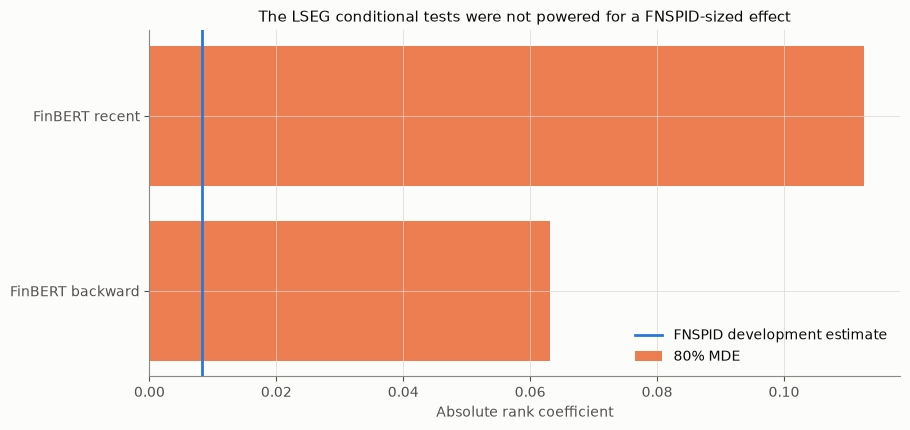

In [4]:
family_summary = (
    mde.groupby(["family", "unit"], as_index=False)
    .agg(
        tests=("test", "size"),
        smallest_abs_estimate=("estimate", lambda values: float(np.min(np.abs(values)))),
        largest_abs_estimate=("estimate", lambda values: float(np.max(np.abs(values)))),
        minimum_mde80=("mde80_nominal", "min"),
        median_mde80=("mde80_nominal", "median"),
        maximum_mde80=("mde80_nominal", "max"),
        median_first_bh_mde80=("mde80_first_bh", "median"),
    )
)
display(family_summary)

lseg_precision = mde.loc[mde["family"].eq("LSEG conditional transfer")].copy()
fig, ax = plt.subplots(figsize=(9.2, 4.4))
y = np.arange(len(lseg_precision))
ax.barh(y, lseg_precision["mde80_nominal"], color=CATEGORICAL[1], alpha=0.85, label="80% MDE")
ax.axvline(abs(fnspid_effect), color=CATEGORICAL[0], linewidth=2, label="FNSPID development estimate")
ax.set_yticks(y)
ax.set_yticklabels(lseg_precision["test"])
ax.set_xlabel("Absolute rank coefficient")
ax.set_title("The LSEG conditional tests were not powered for a FNSPID-sized effect")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT / "lseg_conditional_mde.png", dpi=180, bbox_inches="tight")
plt.show()

## Persist aggregate tables and a dissertation-ready LaTeX summary

In [5]:
input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
threshold_reproduction.to_csv(OUTPUT / "threshold_bootstrap_reproduction.csv", index=False)
mde.to_csv(OUTPUT / "minimum_detectable_effects.csv", index=False)
family_summary.to_csv(OUTPUT / "mde_family_summary.csv", index=False)

latex_rows = []
for row in family_summary.itertuples():
    family = str(row.family).replace("&", r"\&")
    unit = str(row.unit).replace("&", r"\&")
    latex_rows.append(
        f"{family} & {row.tests:d} & {row.median_mde80:.3f} & {row.median_first_bh_mde80:.3f} & {unit} \\\\"
    )
latex = "\n".join(
    [
        "% Generated by Notebook 77; see its manifest for hashes and seeds.",
        r"\begin{table}[htbp]",
        r"\centering",
        r"\small",
        r"\caption{Minimum detectable effects for the principal null families}",
        r"\label{tab:null-mde}",
        r"\begin{tabular}{p{4.2cm}rrrp{4.2cm}}",
        r"\toprule",
        r"Family & Tests & Median MDE & Conservative BH MDE & Unit \\",
        r"\midrule",
        *latex_rows,
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
        "",
    ]
)
TABLE_OUTPUT.write_text(latex)

git_commit = subprocess.run(
    ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
).stdout.strip()
manifest = {
    "notebook": "77_null_minimum_detectable_effects",
    "status": "complete_precision_audit_on_opened_aggregate_results",
    "git_commit_at_execution": git_commit,
    "declared_spec": str(SPEC_PATH.relative_to(ROOT)),
    "declared_spec_sha256": sha256(SPEC_PATH),
    "alpha_two_sided": ALPHA,
    "power": POWER,
    "nominal_multiplier": mde_multiplier(ALPHA, POWER),
    "inputs": {str(path.relative_to(ROOT)): sha256(path) for path in PATHS.values()},
    "threshold_reproduction": json.loads(threshold_reproduction.to_json(orient="records")),
    "threshold_paired_bootstrap_seed": THRESHOLD_PAIRED_SEED,
    "family_summary": json.loads(family_summary.to_json(orient="records")),
    "claim_boundary": spec["claim_boundary"],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

backward = lseg_precision.loc[lseg_precision["test"].eq("FinBERT backward")].iloc[0]
recent = lseg_precision.loc[lseg_precision["test"].eq("FinBERT recent")].iloc[0]
display(
    Markdown(
        f"""### Precision result

- The backward LSEG block's nominal 80% MDE is **{backward['mde80_nominal']:.4f} rank units**, or
  **{backward['nominal_mde_multiple_of_reference']:.1f} times** the absolute FNSPID estimate.
- The recent LSEG block's nominal 80% MDE is **{recent['mde80_nominal']:.4f}**, or
  **{recent['nominal_mde_multiple_of_reference']:.1f} times** the FNSPID estimate.

Those coefficient nulls are therefore low-precision portability tests. The
table gives the corresponding economic-unit detection limits for story type,
publisher, earnings conditioning and learned thresholds. None of these MDEs
proves an exact zero; they state what the completed designs could rule out.
"""
    )
)

### Precision result

- The backward LSEG block's nominal 80% MDE is **0.0632 rank units**, or
  **7.6 times** the absolute FNSPID estimate.
- The recent LSEG block's nominal 80% MDE is **0.1126**, or
  **13.6 times** the FNSPID estimate.

Those coefficient nulls are therefore low-precision portability tests. The
table gives the corresponding economic-unit detection limits for story type,
publisher, earnings conditioning and learned thresholds. None of these MDEs
proves an exact zero; they state what the completed designs could rule out.
